<a href="https://colab.research.google.com/github/ninamircicnm/movie-analytics-pipeline/blob/main/movie_analytics_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Analiza popularnosti filmova integracijom korisničkih ocjena i vanjskih izvora podataka

Nina Mirčić

Programiranje za analizu podataka

Varaždin, 2026.

## Uvod

Filmovi i filmska industrija uvijek su bili popularni te sada dobivaju novi segment razvojem generativne umjetne inteligencije. Zbog toga sustavna analiza prošlih trendova u ovoj industriji može biti znatno od koristi.

Uvijek kada biram film, gledam ocjene korisnika te sam vidjela da se IMDb ocjene mogu razlikovati od samih korisničkih ocjena. Nadalje, svjesna sam činjenice da filmska industrija generira ogromne količine podataka. Ako krenemo samo od osnovnih informacija o filmu kao što su redatelj, glumci, naslov, datum prikazivanja, žanr, možemo vidjeti da ubrzo dolazimo do velikih količina podataka, a da pritome nismo uključili korisničke ocjene niti financijske pokazatelje. Iz toga se može zaključiti da analiza takvih podataka može pokazati i otkriti zanimljive informacije, što je temelj kolegija Programiranje za nalizu podataka.


Cilj je projekta napraviti analizu popularnosti filmova koristeći heterogrne izvore podataka te vidjeti koji su žanrovi najpopularniji kroz godine, postoji li korelacija između box office prihoda i ocjena te analizirati kako se to IMDb ocjene razlikuju od ocjena profesionalnih kritičara.

Prvo će se prikupiti i integrirati podaci iz različitih izvora, odnosno jedan set podataka o filmovima dohvatit ce se u CSV formatu preko Kaggle Dataseta, dok će se drugom pristupiti putem OMDb API-ja. Zatim će se provesti čišćenje i normalizacija podataka kako bi se mogla izračunati sama popularnost filmova, odnosno provesti analiza filmske industrije. Sljedeći korak jest podatke spremiti u relacijsku bazu te kreirati REST API sučelje za pristup podacima. Kao zadnji korak potrebno je analizirati trendove kao što su trendovi po godinama, top filmove i usporedba IMDb i Metascore ocjena. Dobivene rezultate potrebno je vizualizirati kroz linijske, stupčaste i raspršene dijagrame.

##Opis implementacije

In [ ]:
# Za lokalno pokretanje: instaliraj python-dotenv i kreiraj .env datoteku
# Za Colab: koristi Secrets (ključić u lijevom izborniku)

In [ ]:
!pip install -q kagglehub
!pip install -q sqlalchemy

In [2]:
# import biblioteka potrebnih za rad
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import time
import json
from datetime import datetime
from sqlalchemy import create_engine, text, inspect
import warnings
warnings.filterwarnings('ignore')
import os
import kagglehub
from collections import Counter

In [ ]:
#dodatne postavke za ksaniju vizualizaciju
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 10
%matplotlib inline

###Prikupljanje podataka

####Kaggle Dataset

Kao što sam već prethodno navela prvi skup podataka bit će IMDB Dataset of Top 1000 Movies and TV Shows [1] koji se automatski preuzima putem kagglehub biblioteke u csv formatu.

In [ ]:
# preuzimanje dataseta
path = kagglehub.dataset_download("harshitshankhdhar/imdb-dataset-of-top-1000-movies-and-tv-shows")

#pronaćaženje CSV datoteke
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]

#učitavanje datoteke kao dataframe
csv_path = os.path.join(path, csv_files[0])
df_kaggle = pd.read_csv(csv_path)

print(f"Učitano {len(df_kaggle)} filmova iz Kaggle dataseta")

Using Colab cache for faster access to the 'imdb-dataset-of-top-1000-movies-and-tv-shows' dataset.
Učitano 1000 filmova iz Kaggle dataseta


In [ ]:
#učitavanje prvih nekoliko redaka iz dataseta
df_kaggle.head()

,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469"
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411"
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444"
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,"57,300,000"
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,"4,360,000"


In [ ]:
df_kaggle.duplicated().sum()

np.int64(0)

In [ ]:
df_kaggle.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Poster_Link    1000 non-null   object 
 1   Series_Title   1000 non-null   object 
 2   Released_Year  1000 non-null   object 
 3   Certificate    899 non-null    object 
 4   Runtime        1000 non-null   object 
 5   Genre          1000 non-null   object 
 6   IMDB_Rating    1000 non-null   float64
 7   Overview       1000 non-null   object 
 8   Meta_score     843 non-null    float64
 9   Director       1000 non-null   object 
 10  Star1          1000 non-null   object 
 11  Star2          1000 non-null   object 
 12  Star3          1000 non-null   object 
 13  Star4          1000 non-null   object 
 14  No_of_Votes    1000 non-null   int64  
 15  Gross          831 non-null    object 
dtypes: float64(2), int64(1), object(13)
memory usage: 125.1+ KB


Uvidom u podatke i njihove tipove vidi se da će se morati napraviti konverzija određenih podataka kao što je Released_Year, prvi stupac s linkom za poster možemo izbaciti, U Runtime moramo izbaciti nastavak min. Također možemo vidjeti da za neke vrijednosti nemamo podatke.

####OMDb API

Za drugi izvor podataka, odabrala sam OMDb (Open Movie Database) koji je REST API te vraća podatke o filmovima u JSON formatu. Kada se pošalje HTTP zahtjev s parametrima, dobiva se JSON odgovor s informacijama.

S obzirom da je OMDb besplatni web servis, ima na besplatnom planu ograničenje od 1000 zahtjeva po danu, uzimat će se manji broj podataka iz ovog izvora te će se zahtjevi slati s 0,3-0,5s pauze između zahtjeva.

POdaci koje ću uzeti s OMDb API jesu Box Office prihodi, detaljne ocjene (IMDb, Rotten Tomatoes, Metacritic), Produkcijske kuće, nagrade i nominacije te puni opis radnje.

In [3]:
#API pristupni podaci
from google.colab import userdata

OMDB_API_KEY = userdata.get('OMDB_API_KEY')
OMDB_BASE_URL = "http://www.omdbapi.com/"

print(f"OMDb API konfiguriran s ključem: {OMDB_API_KEY[:4]}****")

OMDb API konfiguriran s ključem: 2ffc****


Kako bi dohvatili podatke preko API definirat će se funkcija koja će kao argumente primati parametre naslov i godinu filma radi veće preciznosti jer možda neki filmovi imaju isti naziv, a različite godine izlaska. Statički argument funkcije jest sami API ključ. funkcija vraća riječnik s podacima ako je film nađen, inače vraća prazan zapis. U funkcije se odmah provodi parsiranje jer se podaci dohvaćaju u JSON formatu.

In [ ]:
#funkcija za dohvat podataka preko API
def get_omdb_data(title, year=None, api_key=OMDB_API_KEY):

    # Priprema parametara za API zahtjev
    params = {
        'apikey': api_key,
        't': title,
        'type': 'movie',
        'plot': 'full'
    }

    # Dodaj godinu ako je navedena
    if year:
        params['y'] = str(year)  # y = year

    try:
        # Pošalji GET zahtjev prema API-ju
        response = requests.get(OMDB_BASE_URL, params=params, timeout=10)

        # Provjeri HTTP status code (200 = uspješno)
        response.raise_for_status()

        # Parsiraj JSON odgovor
        data = response.json()

        # Provjeri je li API pronašao film
        # API vraća Response: "True" ako je film pronađen
        if data.get('Response') == 'True':
            return data
        else:
            # Film nije pronađen - API vraća Error message
            error_msg = data.get('Error', 'Nepoznata greška')
            # print(f"'{title}': {error_msg}")
            return None

    except requests.exceptions.Timeout:
        print(f"Timeout za film '{title}'")
        return None
    except requests.exceptions.RequestException as e:
        print(f"HTTP greška za '{title}': {e}")
        return None
    except json.JSONDecodeError:
        print(f"Greška pri parsiranju JSON-a za '{title}'")
        return None

In [ ]:
# Testiranje konekcije s poznatim filmom
test_movie = get_omdb_data("The Matrix", 1999)

if test_movie:
    print("API radi uspješno!\n")
    print(f"Film: {test_movie.get('Title')}")
    print(f"Godina: {test_movie.get('Year')}")
    print(f"IMDb ocjena: {test_movie.get('imdbRating')}/10")
    print(f"Box Office: {test_movie.get('BoxOffice')}")
    print(f"Nagrade: {test_movie.get('Awards')}")
    print(f"Metascore: {test_movie.get('Metascore')}")
else:
    print("API test nije uspio - provjerite API ključ ili internet vezu")


API radi uspješno!

Film: The Matrix
Godina: 1999
IMDb ocjena: 8.7/10
Box Office: $177,559,005
Nagrade: Won 4 Oscars. 42 wins & 52 nominations total
Metascore: 73


Nakon što se testirala API konekcija, može prijeći na veće dohvaćanje podataka. Plan je s obzirom da u Kaggle Datasetu imamo neke osnovne informacije te informacije obogatimo podacima iz OMDb API-ja. Za demosnstraciju će se koristiti uzorak od prvih 200 filmova jer imamo ograničenje broj zahtjeva.

In [ ]:
 #Definiranje veličine uzorka
SAMPLE_SIZE = 200

print(f"\nDohvaćam filmove preko OMDb API ")
print("Molim pričekajte, dohvat može potrajati...\n")

# Uzmi uzorak filmova
df_sample = df_kaggle.head(SAMPLE_SIZE).copy()

# Lista za spremanje OMDb podataka
omdb_data_list = []

# Iteriraj kroz svaki film
for idx, row in df_sample.iterrows():
    # Izvuci naslov i godinu iz Kaggle dataseta
    title = row['Series_Title']

    # čišćenje godine
    year_raw = str(row['Released_Year']).strip()
    try:
        year = int(year_raw) if year_raw.isdigit() else None
    except:
        year = None

    # Dohvati podatke iz OMDb API-ja
    movie_data = get_omdb_data(title, year)

    if movie_data:
        # Uspješno dohvaćeni podaci
        omdb_data_list.append({
            # Osnovni identifikatori
            'Title': title,
            'imdbID': movie_data.get('imdbID', 'N/A'),

            # Financijski pokazatelji
            'BoxOffice': movie_data.get('BoxOffice', 'N/A'),

            # Ocjene iz različitih izvora
            'Metascore': movie_data.get('Metascore', 'N/A'),
            'imdbRating_OMDB': movie_data.get('imdbRating', 'N/A'),
            'imdbVotes': movie_data.get('imdbVotes', 'N/A'),

            # Dodatne informacije
            'Rated': movie_data.get('Rated', 'N/A'),
            'Runtime_OMDB': movie_data.get('Runtime', 'N/A'),
            'Genre_OMDB': movie_data.get('Genre', 'N/A'),

            'Country': movie_data.get('Country', 'N/A'),
            'Language': movie_data.get('Language', 'N/A'),

            # Nagrade i priznanja
            'Awards': movie_data.get('Awards', 'N/A'),

            # Detaljne ocjene (lista rječnika)
            'Ratings': movie_data.get('Ratings', [])
        })
    else:
        # Nisu pronađeni podaci - dodaj prazan zapis
        omdb_data_list.append({
            'Title': title,
            'imdbID': 'N/A',
            'BoxOffice': 'N/A',
            'Metascore': 'N/A',
            'imdbRating_OMDB': 'N/A',
            'imdbVotes': 'N/A',
            'Rated': 'N/A',
            'Runtime_OMDB': 'N/A',
            'Genre_OMDB': 'N/A',
            'Country': 'N/A',
            'Language': 'N/A',
            'Awards': 'N/A',
            'Ratings': []
        })

    # Rate limiting - pauza između zahtjeva
    time.sleep(0.4)  # 400ms pauza = ~150 zahtjeva/min

print(f"Dohvaćeno {len(omdb_data_list)} filmova iz OMDb API-ja")



Dohvaćam filmove preko OMDb API 
Molim pričekajte, dohvat može potrajati...

Dohvaćeno 200 filmova iz OMDb API-ja


In [ ]:
# Kreiranje DataFrame iz OMDb podataka
df_omdb = pd.DataFrame(omdb_data_list)
df_omdb.head()

,Title,imdbID,BoxOffice,Metascore,imdbRating_OMDB,imdbVotes,Rated,Runtime_OMDB,Genre_OMDB,Country,Language,Awards,Ratings
0,The Shawshank Redemption,tt0111161,"$28,767,189",82,9.3,"3,136,948",R,142 min,Drama,United States,English,Nominated for 7 Oscars. 21 wins & 42 nominatio...,"[{'Source': 'Internet Movie Database', 'Value'..."
1,The Godfather,tt0068646,"$136,381,073",100,9.2,"2,190,120",R,175 min,"Crime, Drama",United States,"English, Italian, Latin",Won 3 Oscars. 31 wins & 31 nominations total,"[{'Source': 'Internet Movie Database', 'Value'..."
2,The Dark Knight,tt0468569,"$534,987,076",85,9.1,"3,115,102",PG-13,152 min,"Action, Crime, Drama","United States, United Kingdom","English, Mandarin",Won 2 Oscars. 163 wins & 165 nominations total,"[{'Source': 'Internet Movie Database', 'Value'..."
3,The Godfather: Part II,tt0071562,"$47,834,595",90,9.0,"1,472,464",R,202 min,"Crime, Drama",United States,"English, Italian, Spanish, Latin, Sicilian",Won 6 Oscars. 17 wins & 21 nominations total,"[{'Source': 'Internet Movie Database', 'Value'..."
4,12 Angry Men,tt0050083,N/A,97,9.0,"965,680",Approved,96 min,"Crime, Drama",United States,English,Nominated for 3 Oscars. 16 wins & 12 nominatio...,"[{'Source': 'Internet Movie Database', 'Value'..."


In [ ]:
df_omdb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Title            200 non-null    object
 1   imdbID           200 non-null    object
 2   BoxOffice        200 non-null    object
 3   Metascore        200 non-null    object
 4   imdbRating_OMDB  200 non-null    object
 5   imdbVotes        200 non-null    object
 6   Rated            200 non-null    object
 7   Runtime_OMDB     200 non-null    object
 8   Genre_OMDB       200 non-null    object
 9   Country          200 non-null    object
 10  Language         200 non-null    object
 11  Awards           200 non-null    object
 12  Ratings          200 non-null    object
dtypes: object(13)
memory usage: 20.4+ KB


Uvidom u podatke možemo vidjeti da smo uspješno pronašli i prikupili podatke za 200 filmova. Svi podatci su kategorički iako bi neki od njih trebali biti numerički. BoxOffice stupac sadrži zareze i posebni znak za dolar $, što j epotrebno ukloniti prije rada s podacima.

###Pretprocesiranaje i integracija podataka iz više skupova

####Predrocesiranje

Jedan od glavih koraka u analizi podataka jest sam priprema podataka, odnosno predprocesiranje prije samog rada s podacima. Ono uključuje čišćenje podataka, uklanjanje nepotrebnih stupaca, konverzija podataka, normalizaciju, parsiranje i slično kako bi se moglo ispravno raditi s podacima. Uvidom u skupove koje sam odabrala za rad, naglašeni su neki od problema s podacima koji će se u ovom poglavlju otkloniti.

Za ovu obradu podataka koristila sam sintaku koja se nalazi u osonovnoj literaturi kolegija, odnosno Python for data Analysis [3].

S obzirom da sam podatke preko API dohvaćala po uzorku ostatak projekta odlučila sam raditi na istom to uzorku.



#####Predprocesiranje Kaggle uzorka

In [ ]:
df_clean_kaggle=df_sample.copy()

In [ ]:
df_clean_kaggle.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Poster_Link    200 non-null    object 
 1   Series_Title   200 non-null    object 
 2   Released_Year  200 non-null    object 
 3   Certificate    188 non-null    object 
 4   Runtime        200 non-null    object 
 5   Genre          200 non-null    object 
 6   IMDB_Rating    200 non-null    float64
 7   Overview       200 non-null    object 
 8   Meta_score     152 non-null    float64
 9   Director       200 non-null    object 
 10  Star1          200 non-null    object 
 11  Star2          200 non-null    object 
 12  Star3          200 non-null    object 
 13  Star4          200 non-null    object 
 14  No_of_Votes    200 non-null    int64  
 15  Gross          166 non-null    object 
dtypes: float64(2), int64(1), object(13)
memory usage: 25.1+ KB


In [ ]:
#čišćenje godine jer nije brojčani zapis
df_clean_kaggle['Released_Year'] = df_clean_kaggle['Released_Year'].astype(str).str.strip()
df_clean_kaggle['Released_Year'] = pd.to_numeric(df_clean_kaggle['Released_Year'], errors='coerce')


In [ ]:
#čišćenje runtime, uklanjanje min iz stupca
if 'Runtime' in df_clean_kaggle.columns:
    df_clean_kaggle['Runtime_Minutes'] = df_clean_kaggle['Runtime'].str.replace(' min', '').str.strip()
    df_clean_kaggle['Runtime_Minutes'] = pd.to_numeric(df_clean_kaggle['Runtime_Minutes'], errors='coerce')


In [ ]:
#Brisanje stupca Poster Link jer nam nije relevantan za analizu
df_clean_kaggle.drop(columns=['Poster_Link'], inplace=True)

#brisanje Runtime jer imamo, novi stupac bez nastavka min
df_clean_kaggle.drop(columns=['Runtime'], inplace=True)

In [ ]:
#parsiranje žanrova
df_clean_kaggle['Genre_List'] = df_clean_kaggle['Genre'].str.split(', ')

In [ ]:
df_clean_kaggle.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Series_Title     200 non-null    object 
 1   Released_Year    200 non-null    int64  
 2   Certificate      188 non-null    object 
 3   Genre            200 non-null    object 
 4   IMDB_Rating      200 non-null    float64
 5   Overview         200 non-null    object 
 6   Meta_score       152 non-null    float64
 7   Director         200 non-null    object 
 8   Star1            200 non-null    object 
 9   Star2            200 non-null    object 
 10  Star3            200 non-null    object 
 11  Star4            200 non-null    object 
 12  No_of_Votes      200 non-null    int64  
 13  Gross            166 non-null    object 
 14  Runtime_Minutes  200 non-null    int64  
 15  Genre_List       200 non-null    object 
dtypes: float64(2), int64(3), object(11)
memory usage: 25.1+ KB


In [ ]:
df_clean_kaggle.head()

,Series_Title,Released_Year,Certificate,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross,Runtime_Minutes,Genre_List
0,The Shawshank Redemption,1994,A,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469",142,[Drama]
1,The Godfather,1972,A,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411",175,"[Crime, Drama]"
2,The Dark Knight,2008,UA,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444",152,"[Action, Crime, Drama]"
3,The Godfather: Part II,1974,A,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,"57,300,000",202,"[Crime, Drama]"
4,12 Angry Men,1957,U,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,"4,360,000",96,"[Crime, Drama]"


#####Predprocesiranje podataka OMDb API

In [ ]:
df_clean_omdb = df_omdb.copy()

In [ ]:
df_clean_omdb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Title            200 non-null    object
 1   imdbID           200 non-null    object
 2   BoxOffice        200 non-null    object
 3   Metascore        200 non-null    object
 4   imdbRating_OMDB  200 non-null    object
 5   imdbVotes        200 non-null    object
 6   Rated            200 non-null    object
 7   Runtime_OMDB     200 non-null    object
 8   Genre_OMDB       200 non-null    object
 9   Country          200 non-null    object
 10  Language         200 non-null    object
 11  Awards           200 non-null    object
 12  Ratings          200 non-null    object
dtypes: object(13)
memory usage: 20.4+ KB


In [ ]:
# Čišćenje Box Office podataka (ukloni $ i ,)
df_clean_omdb['BoxOffice_Clean'] = df_clean_omdb['BoxOffice'].replace('N/A', np.nan)
df_clean_omdb['BoxOffice_Clean'] = df_clean_omdb['BoxOffice_Clean'].str.replace('$', '').str.replace(',', '')
df_clean_omdb['BoxOffice_Clean'] = pd.to_numeric(df_clean_omdb['BoxOffice_Clean'], errors='coerce')


In [ ]:
# Čišćenje Metascore i imdbRating_OMDB
df_clean_omdb['Metascore_Clean'] = pd.to_numeric(df_clean_omdb['Metascore'].replace('N/A', np.nan), errors='coerce')
df_clean_omdb['imdbRating_OMDB'] = pd.to_numeric(df_clean_omdb['imdbRating_OMDB'].replace('N/A', np.nan), errors='coerce')


In [ ]:
#brisanje stupca rating i imdbID
df_clean_omdb.drop(columns=['Ratings'], inplace=True)
df_clean_omdb.drop(columns=['imdbID'], inplace=True)

In [ ]:
df_clean_omdb.head()

,Title,BoxOffice,Metascore,imdbRating_OMDB,imdbVotes,Rated,Runtime_OMDB,Genre_OMDB,Country,Language,Awards,BoxOffice_Clean,Metascore_Clean
0,The Shawshank Redemption,"$28,767,189",82,9.3,"3,136,948",R,142 min,Drama,United States,English,Nominated for 7 Oscars. 21 wins & 42 nominatio...,28767189.0,82.0
1,The Godfather,"$136,381,073",100,9.2,"2,190,120",R,175 min,"Crime, Drama",United States,"English, Italian, Latin",Won 3 Oscars. 31 wins & 31 nominations total,136381073.0,100.0
2,The Dark Knight,"$534,987,076",85,9.1,"3,115,102",PG-13,152 min,"Action, Crime, Drama","United States, United Kingdom","English, Mandarin",Won 2 Oscars. 163 wins & 165 nominations total,534987076.0,85.0
3,The Godfather: Part II,"$47,834,595",90,9.0,"1,472,464",R,202 min,"Crime, Drama",United States,"English, Italian, Spanish, Latin, Sicilian",Won 6 Oscars. 17 wins & 21 nominations total,47834595.0,90.0
4,12 Angry Men,N/A,97,9.0,"965,680",Approved,96 min,"Crime, Drama",United States,English,Nominated for 3 Oscars. 16 wins & 12 nominatio...,NaN,97.0


In [ ]:
df_clean_omdb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Title            200 non-null    object 
 1   BoxOffice        200 non-null    object 
 2   Metascore        200 non-null    object 
 3   imdbRating_OMDB  159 non-null    float64
 4   imdbVotes        200 non-null    object 
 5   Rated            200 non-null    object 
 6   Runtime_OMDB     200 non-null    object 
 7   Genre_OMDB       200 non-null    object 
 8   Country          200 non-null    object 
 9   Language         200 non-null    object 
 10  Awards           200 non-null    object 
 11  BoxOffice_Clean  130 non-null    float64
 12  Metascore_Clean  129 non-null    float64
dtypes: float64(3), object(10)
memory usage: 20.4+ KB


####Integracija skupova

Nakon sređivanja podataka u oba skupa, vrijeme je za njihovu integraciju u jedan skup kako bi mogli žreći na njihovo prikazivanje te analizu. Odlučeno je podatke iz oba skupa spojiti prema naslovu te s obzirom da u kaggle datasetu nemamo neke podatke, a njih smo upjeli naći u OMDb movie setu, uzet će se podaci iz tog skupa kako u konačnom skupu za analizu ne bi bilo nedostajućih vrijednosti.

In [ ]:
df_integrated = df_clean_kaggle.merge(
    df_clean_omdb,
    left_on='Series_Title',
    right_on='Title',
    how='left',
    suffixes=('_kaggle', '_omdb')
)
print(f"Integrirani skup ima {len(df_integrated)} redaka i {len(df_integrated.columns)} stupaca")


Integrirani skup ima 202 redaka i 29 stupaca


In [ ]:
df_integrated.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 202 entries, 0 to 201
Data columns (total 29 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Series_Title     202 non-null    object 
 1   Released_Year    202 non-null    int64  
 2   Certificate      190 non-null    object 
 3   Genre            202 non-null    object 
 4   IMDB_Rating      202 non-null    float64
 5   Overview         202 non-null    object 
 6   Meta_score       152 non-null    float64
 7   Director         202 non-null    object 
 8   Star1            202 non-null    object 
 9   Star2            202 non-null    object 
 10  Star3            202 non-null    object 
 11  Star4            202 non-null    object 
 12  No_of_Votes      202 non-null    int64  
 13  Gross            167 non-null    object 
 14  Runtime_Minutes  202 non-null    int64  
 15  Genre_List       202 non-null    object 
 16  Title            202 non-null    object 
 17  BoxOffice       

In [ ]:
df_integrated.head()

,Series_Title,Released_Year,Certificate,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,...,imdbRating_OMDB,imdbVotes,Rated,Runtime_OMDB,Genre_OMDB,Country,Language,Awards,BoxOffice_Clean,Metascore_Clean
0,The Shawshank Redemption,1994,A,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,...,9.3,"3,136,948",R,142 min,Drama,United States,English,Nominated for 7 Oscars. 21 wins & 42 nominatio...,28767189.0,82.0
1,The Godfather,1972,A,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,...,9.2,"2,190,120",R,175 min,"Crime, Drama",United States,"English, Italian, Latin",Won 3 Oscars. 31 wins & 31 nominations total,136381073.0,100.0
2,The Dark Knight,2008,UA,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,...,9.1,"3,115,102",PG-13,152 min,"Action, Crime, Drama","United States, United Kingdom","English, Mandarin",Won 2 Oscars. 163 wins & 165 nominations total,534987076.0,85.0
3,The Godfather: Part II,1974,A,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,...,9.0,"1,472,464",R,202 min,"Crime, Drama",United States,"English, Italian, Spanish, Latin, Sicilian",Won 6 Oscars. 17 wins & 21 nominations total,47834595.0,90.0
4,12 Angry Men,1957,U,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,...,9.0,"965,680",Approved,96 min,"Crime, Drama",United States,English,Nominated for 3 Oscars. 16 wins & 12 nominatio...,NaN,97.0


Integracijom oba skupa prema zajedničkom nazivu vidimo da imamo dosta podataka, nedostajućih vrijednosti, dupliciranih stupaca. Prije pohrane takvog skupa potrebno je podatke ponovno srediti i predprocesirati.

#####Predprocesiranje integriranog skupa

In [ ]:
df_final = df_integrated.copy()

In [ ]:
# Uklanjamo Title jer imamo Series_Title
if 'Title' in df_final.columns:
    df_final.drop(columns=['Title'], inplace=True)

In [ ]:
#brisanje dva stupca sa žanrom s obzirom da imamo u skupu tri
if 'Genre_OMDB' in df_final.columns:
    df_final.drop(columns=['Genre_OMDB'], inplace=True)


In [ ]:
#ostavljamo samo Runtime_minutes jer je sređen stupac
if 'Runtime_OMDB' in df_final.columns:
    df_final.drop(columns=['Runtime_OMDB'], inplace=True)


In [ ]:
#brisanje imdbVotes jer imamo No_of_Votes
if 'imdbVotes' in df_final.columns:
    df_final.drop(columns=['imdbVotes'], inplace=True)

In [ ]:
#rad s ocjenama
if 'imdbRating_OMDB' in df_final.columns:
    # Popuni nedostajuće IMDB_Rating vrijednosti s OMDB podacima
    mask = df_final['IMDB_Rating'].isnull()
    df_final.loc[mask, 'IMDB_Rating'] = df_final.loc[mask, 'imdbRating_OMDB']

    # Provjeri razlike (za analizu)
    diff_count = (df_final['IMDB_Rating'] != df_final['imdbRating_OMDB']).sum()

    # Briši OMDB stupac
    df_final.drop(columns=['imdbRating_OMDB'], inplace=True)
    print(f"IMDB_Rating konsolidiran (pronađeno {diff_count} razlika između izvora)")

IMDB_Rating konsolidiran (pronađeno 107 razlika između izvora)


In [ ]:
#čišćenje Meta_score
if 'Metascore_Clean' in df_final.columns and 'Meta_score' in df_final.columns:
    # Popuni nedostajuće Meta_score s Metascore_Clean
    mask = df_final['Meta_score'].isnull()
    df_final.loc[mask, 'Meta_score'] = df_final.loc[mask, 'Metascore_Clean']

    # Briši Metascore i Metascore_Clean
    df_final.drop(columns=['Metascore', 'Metascore_Clean'], inplace=True)
    print("Meta_score očišćen")

Meta_score očišćen


In [ ]:
#BoxOffice i Gross imaju istu funkciju
if 'Gross' in df_final.columns:
    df_final['Gross_Clean'] = df_final['Gross'].str.replace(',', '').str.strip()
    df_final['Gross_Clean'] = pd.to_numeric(df_final['Gross_Clean'], errors='coerce')

# Kreiraj finalni BoxOffice stupac - prioritet Kaggle, zatim OMDB
df_final['BoxOffice_USD'] = df_final['Gross_Clean'].fillna(df_final['BoxOffice_Clean'])

# Ukloni privremene stupce
df_final.drop(columns=['Gross', 'Gross_Clean', 'BoxOffice', 'BoxOffice_Clean'],
              inplace=True, errors='ignore')

In [ ]:
#popunjavanje nedostajućih vrijednosti

In [ ]:
#ako cetrifikat nije popunjen stavlja se not rated
if 'Certificate' in df_final.columns:
    missing_before = df_final['Certificate'].isnull().sum()
    df_final['Certificate'].fillna('Not Rated', inplace=True)

In [ ]:
#rated se isto popunja s Not rated i mijenja se N/A
if 'Rated' in df_final.columns:
    df_final['Rated'] = df_final['Rated'].replace('N/A', 'Not Rated')
    missing_before = df_final['Rated'].isnull().sum()
    df_final['Rated'].fillna('Not Rated', inplace=True)

In [ ]:
#Awards se popunjavaju s No awards
if 'Awards' in df_final.columns:
    df_final['Awards'] = df_final['Awards'].replace('N/A', 'No awards')
    missing_before = df_final['Awards'].isnull().sum()
    df_final['Awards'].fillna('No awards', inplace=True)

In [ ]:
#u slučaju da nije poznata zemlja ili jezik stavlje se nepoznato
if 'Country' in df_final.columns:
    df_final['Country'] = df_final['Country'].replace('N/A', 'Unknown')
    missing_before = df_final['Country'].isnull().sum()
    df_final['Country'].fillna('Unknown', inplace=True)

if 'Language' in df_final.columns:
    df_final['Language'] = df_final['Language'].replace('N/A', 'Unknown')
    missing_before = df_final['Language'].isnull().sum()
    df_final['Language'].fillna('Unknown', inplace=True)

s obzirom kako nam je za Meta_score i BoxOffice bitno da imamo i Nan radi analize korelacije njih ostavljam i ne sređujem dalje

Reorganizacija stupaca radi ljepšeg prikaza podataka

In [ ]:

desired_columns = [
    # Osnovne informacije
    'Series_Title',
    'Released_Year',
    'Director',
    'Genre',
    'Genre_List',
    'Runtime_Minutes',

    # Ocjene
    'IMDB_Rating',
    'Meta_score',
    'No_of_Votes',

    # Financijski podaci
    'BoxOffice_USD',

    # Certifikati i klasifikacije
    'Certificate',
    'Rated',

    # Glumci
    'Star1',
    'Star2',
    'Star3',
    'Star4',

    # Dodatne informacije
    'Country',
    'Language',
    'Awards',
    'Overview'
]

# Filtriraj samo stupce koji postoje
available_columns = [col for col in desired_columns if col in df_final.columns]

# Dodaj sve ostale stupce koje nismo eksplicitno naveli
other_columns = [col for col in df_final.columns if col not in available_columns]
final_column_order = available_columns + other_columns

# Reorgiraniziraj
df_final = df_final[final_column_order]

In [ ]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 202 entries, 0 to 201
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Series_Title     202 non-null    object 
 1   Released_Year    202 non-null    int64  
 2   Director         202 non-null    object 
 3   Genre            202 non-null    object 
 4   Genre_List       202 non-null    object 
 5   Runtime_Minutes  202 non-null    int64  
 6   IMDB_Rating      202 non-null    float64
 7   Meta_score       157 non-null    float64
 8   No_of_Votes      202 non-null    int64  
 9   BoxOffice_USD    171 non-null    float64
 10  Certificate      202 non-null    object 
 11  Rated            202 non-null    object 
 12  Star1            202 non-null    object 
 13  Star2            202 non-null    object 
 14  Star3            202 non-null    object 
 15  Star4            202 non-null    object 
 16  Country          202 non-null    object 
 17  Language        

In [ ]:
df_final.head()

,Series_Title,Released_Year,Director,Genre,Genre_List,Runtime_Minutes,IMDB_Rating,Meta_score,No_of_Votes,BoxOffice_USD,Certificate,Rated,Star1,Star2,Star3,Star4,Country,Language,Awards,Overview
0,The Shawshank Redemption,1994,Frank Darabont,Drama,[Drama],142,9.3,80.0,2343110,28341469.0,A,R,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,United States,English,Nominated for 7 Oscars. 21 wins & 42 nominatio...,Two imprisoned men bond over a number of years...
1,The Godfather,1972,Francis Ford Coppola,"Crime, Drama","[Crime, Drama]",175,9.2,100.0,1620367,134966411.0,A,R,Marlon Brando,Al Pacino,James Caan,Diane Keaton,United States,"English, Italian, Latin",Won 3 Oscars. 31 wins & 31 nominations total,An organized crime dynasty's aging patriarch t...
2,The Dark Knight,2008,Christopher Nolan,"Action, Crime, Drama","[Action, Crime, Drama]",152,9.0,84.0,2303232,534858444.0,UA,PG-13,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,"United States, United Kingdom","English, Mandarin",Won 2 Oscars. 163 wins & 165 nominations total,When the menace known as the Joker wreaks havo...
3,The Godfather: Part II,1974,Francis Ford Coppola,"Crime, Drama","[Crime, Drama]",202,9.0,90.0,1129952,57300000.0,A,R,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,United States,"English, Italian, Spanish, Latin, Sicilian",Won 6 Oscars. 17 wins & 21 nominations total,The early life and career of Vito Corleone in ...
4,12 Angry Men,1957,Sidney Lumet,"Crime, Drama","[Crime, Drama]",96,9.0,96.0,689845,4360000.0,U,Approved,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,United States,English,Nominated for 3 Oscars. 16 wins & 12 nominatio...,A jury holdout attempts to prevent a miscarria...


Nakon sređivanja možemo vidjeti da imamo devet stupaca manje, tipovi podataka odgovaraju svojoj namjeni. Podaci su lijepo struktuirani, idu kronološki, odnosno hijerarhijski od najrelevantnijih do općenitijih.

###Pohrana integriranog skupa

Kako bi omogućili daljnji rad s podacima ovako integrirane, struktuirane i sređene podatke potrebno je spremiti. prije nego što ih pohranim u bazu podataka, pohranit ću ih u csv datoteku kao određeni oblik backupa.  

In [ ]:
output_csv = 'movies_integrated_final.csv'
df_final.to_csv(output_csv, index=False, encoding='utf-8')

####Izrada baze podataka

Koraci u izradi baze u SQLite za ovaj projekt idu tako što se prvo definira ime bazi podataka, kreira se SQLAlchemy engine te spremanje DataFrame u SQLite tablicu.

U bazi sam odlučila napraviti dvije tablice zbog toga što neki filmovi imaju više žanrova.

In [ ]:
db_name = 'movies_database.db'
engine = create_engine(f'sqlite:///{db_name}')

In [ ]:
#kreiranje prve tablice movies bez Genre_List stupca
df_movies = df_final.drop(columns=['Genre_List', 'Genre'], errors='ignore')

df_movies.to_sql(
    name='movies',
    con=engine,
    if_exists='replace',
    index=False
)

202

In [ ]:
#tabica koja služi za normalizaciju
df_genres = df_final[['Series_Title', 'Genre_List']].copy()
df_genres = df_genres.explode('Genre_List')
df_genres = df_genres.rename(columns={'Genre_List': 'Genre'})
df_genres = df_genres.dropna(subset=['Genre'])
df_genres['Genre'] = df_genres['Genre'].str.strip()  # Ukloni razmake

df_genres.to_sql(
    name='movie_genres',
    con=engine,
    if_exists='replace',
    index=False
)

506

In [ ]:
#provjera postojanosti tablica

inspector = inspect(engine)
tables = inspector.get_table_names()

print(f"\n Tablice u bazi: {tables}")


 Tablice u bazi: ['movie_genres', 'movies']


In [ ]:
# Dodavanje ID u movies tablicu
df_movies_with_id = df_movies.reset_index()
df_movies_with_id = df_movies_with_id.rename(columns={'index': 'movie_id'})

# lookup za žanrove
movie_id_map = df_movies_with_id.set_index('Series_Title')['movie_id'].to_dict()
df_genres['movie_id'] = df_genres['Series_Title'].map(movie_id_map)

##### Testiranje baze s nekoliko upita

In [ ]:
# Broj filmova po žanru
query = """
SELECT Genre, COUNT(*) as Broj_filmova
FROM movie_genres
GROUP BY Genre
ORDER BY Broj_filmova DESC
"""
result = pd.read_sql(query, engine)
print(result)

        Genre  Broj_filmova
0       Drama           149
1       Crime            49
2      Action            41
3   Adventure            40
4      Comedy            35
5    Thriller            27
6     Mystery            25
7     Romance            18
8   Biography            18
9         War            17
10     Sci-Fi            15
11  Animation            15
12     Family            13
13    Fantasy            11
14    History             9
15    Western             6
16      Sport             5
17      Music             5
18     Horror             4
19    Musical             2
20  Film-Noir             2


In [ ]:
#Top 10 filmova po zaradi
print("\n TOP 10 FILMOVA PO BOX OFFICE ZARADI:")

query2 = """
SELECT Series_Title, Released_Year,
       ROUND(BoxOffice_USD, 2) as Box_Office,
       IMDB_Rating
FROM movies
WHERE BoxOffice_USD IS NOT NULL
ORDER BY BoxOffice_USD DESC
LIMIT 10
"""
result2 = pd.read_sql(query2, engine)
print(result2)


 TOP 10 FILMOVA PO BOX OFFICE ZARADI:
                                    Series_Title  Released_Year   Box_Office  \
0                              Avengers: Endgame           2019  858373000.0   
1                         Avengers: Infinity War           2018  678815482.0   
2                                The Dark Knight           2008  534858444.0   
3                          The Dark Knight Rises           2012  448139099.0   
4                                  The Lion King           1994  422783777.0   
5                                    Toy Story 3           2010  415004880.0   
6  The Lord of the Rings: The Return of the King           2003  377845905.0   
7          The Lord of the Rings: The Two Towers           2002  342551365.0   
8                                          Joker           2019  335451311.0   
9                                   Forrest Gump           1994  330252182.0   

   IMDB_Rating  
0          8.4  
1          8.4  
2          9.0  
3          8

In [ ]:
#Filmovi s ocjenom većom od 8.5
print("\n FILMOVI S IMDB OCJENOM > 8.5:")
query3 = """
SELECT Series_Title, Released_Year, IMDB_Rating, Director
FROM movies
WHERE IMDB_Rating > 8.5
ORDER BY IMDB_Rating DESC
"""
result3 = pd.read_sql(query3, engine)
print(result3)


 FILMOVI S IMDB OCJENOM > 8.5:
                                         Series_Title  Released_Year  \
0                            The Shawshank Redemption           1994   
1                                       The Godfather           1972   
2                                     The Dark Knight           2008   
3                              The Godfather: Part II           1974   
4                                        12 Angry Men           1957   
5       The Lord of the Rings: The Return of the King           2003   
6                                        Pulp Fiction           1994   
7                                    Schindler's List           1993   
8                                           Inception           2010   
9                                          Fight Club           1999   
10  The Lord of the Rings: The Fellowship of the Ring           2001   
11                                       Forrest Gump           1994   
12                    Il buono, 

In [ ]:
# Prosječna ocjena po žanru
query4 = """
SELECT mg.Genre,
       COUNT(DISTINCT mg.Series_Title) as Broj_filmova,
       ROUND(AVG(m.IMDB_Rating), 2) as Prosjecna_ocjena
FROM movie_genres mg
JOIN movies m ON mg.Series_Title = m.Series_Title
GROUP BY mg.Genre
ORDER BY Prosjecna_ocjena DESC
"""
result4 = pd.read_sql(query4, engine)
print(result4)

        Genre  Broj_filmova  Prosjecna_ocjena
0      Sci-Fi            15              8.42
1     Western             6              8.40
2      Horror             4              8.40
3   Adventure            40              8.40
4      Action            41              8.40
5     Fantasy            11              8.39
6     History             9              8.37
7       Drama           146              8.37
8       Crime            46              8.36
9   Biography            18              8.36
10    Musical             2              8.35
11  Film-Noir             2              8.35
12     Family            13              8.35
13      Music             5              8.34
14    Romance            18              8.33
15    Mystery            24              8.33
16  Animation            15              8.33
17        War            17              8.32
18   Thriller            26              8.31
19     Comedy            35              8.29
20      Sport             5       

##Prikaz rada aplikacije

Kako bi se moglo pristupiti podacima, odlučila sam izraditi REST API sučelje kao što je predstavljeno na vježbama. Prvo je potrebno postaviti ngrok token, spojiti se na bazu podataka te zatim pokrenuti Flask server i Testirat API.

###Izrada sučelja za pristup podacima

In [4]:
!pip install -q pyngrok

In [5]:
#importanje potrebnih biblioteka
from pyngrok import ngrok, conf
from getpass import getpass

####Postavljanje ngrok tokena

Kako bi dobila ngrok token potreno se prvo registrirati na njihovoj stranici te kopirati token.

In [6]:
# Postavi token
auth_token = userdata.get('NGROK_TOKEN')
conf.get_default().auth_token = auth_token

####Razvoj REST API

za ravoj sam se koristila materijalima dostupnim na Moodle. [4]

In [ ]:
#importanje dodatnih biblioteka
import threading
from flask import Flask, jsonify, request


In [ ]:
app = Flask(__name__)
port = "5000"

#spajanje na bazu
db_name = 'movies_database.db'
engine = create_engine(f'sqlite:///{db_name}', echo=False)

#Izvršava SQL upit i vraća rezultat kao DataFrame
def query_db(query, params=None):
    try:
        if params:
            df = pd.read_sql(query, engine, params=params)
        else:
            df = pd.read_sql(query, engine)
        return df
    except Exception as e:
        print(f"Greška u upitu: {e}")
        return None

# ENDPOINT 1: Početna stranica
# Početna stranica s informacijama o API-ju
@app.route("/")
def index():
    return jsonify({
        "message": "Movie Analysis API - Dobrodošli!",
        "endpoints": {
            "/": "Ova stranica - informacije o API-ju",
            "/movies": "Lista svih filmova (GET)",
            "/movies/<limit>": "Lista filmova s ograničenjem (GET)",
            "/movie/<title>": "Dohvat filma po naslovu (GET)",
            "/movies/year/<year>": "Filmovi iz određene godine (GET)",
            "/movies/genre/<genre>": "Filmovi po žanru (GET)",
            "/movies/director/<director>": "Filmovi po redatelju (GET)",
            "/stats": "Statistika baze podataka (GET)",
            "/top-rated": "Top ocijenjeni filmovi (GET)",
            "/top-rated/<limit>": "Top N ocijenjenih filmova (GET)"
        },
        "database": db_name,
        "total_movies": len(query_db("SELECT * FROM movies"))
    })


# ENDPOINT 2: Svi filmovi
# Vraća sve filmove ili prvih N filmova
@app.route("/movies", methods=['GET'])
@app.route("/movies/<int:limit>", methods=['GET'])
def get_movies(limit=10):
    query = f"SELECT * FROM movies LIMIT {limit}"
    df = query_db(query)

    if df is None or df.empty:
        return jsonify({"error": "Nema dostupnih filmova"}), 404

    return jsonify(df.to_dict(orient='records'))

# ENDPOINT 3: Film po naslovu
#Dohvaća film prema naslovu"

@app.route("/movie/<title>", methods=['GET'])
def get_movie(title):
    query = "SELECT * FROM movies WHERE Series_Title LIKE ?"
    df = query_db(query, params=(f'%{title}%',))

    if df is None or df.empty:
        return jsonify({"error": f"Film '{title}' nije pronađen"}), 404

    # Vrati prvi pronađeni film
    return jsonify(df.iloc[0].to_dict())

# ENDPOINT 4: Filmovi po godini
# Dohvaća filmove iz određene godine

@app.route("/movies/year/<int:year>", methods=['GET'])
def get_movies_by_year(year):
    query = "SELECT * FROM movies WHERE Released_Year = ?"
    df = query_db(query, params=(year,))

    if df is None or df.empty:
        return jsonify({"error": f"Nema filmova iz {year}. godine"}), 404

    return jsonify({
        "year": year,
        "count": len(df),
        "movies": df.to_dict(orient='records')
    })

# ENDPOINT 5: Filmovi po žanru
# Dohvaća filmove prema žanru

@app.route("/movies/genre/<genre>", methods=['GET'])
def get_movies_by_genre(genre):
    query = "SELECT * FROM movie_genres WHERE Genre LIKE ?"
    df = query_db(query, params=(f'%{genre}%',))

    if df is None or df.empty:
        return jsonify({"error": f"Nema filmova žanra '{genre}'"}), 404

    return jsonify({
        "genre": genre,
        "count": len(df),
        "movies": df.to_dict(orient='records')
    })

# ENDPOINT 6: Filmovi po redatelju
# Dohvaća filmove određenog redatelja

@app.route("/movies/director/<director>", methods=['GET'])
def get_movies_by_director(director):
    query = "SELECT * FROM movies WHERE Director LIKE ?"
    df = query_db(query, params=(f'%{director}%',))

    if df is None or df.empty:
        return jsonify({"error": f"Nema filmova redatelja '{director}'"}), 404

    return jsonify({
        "director": director,
        "count": len(df),
        "movies": df.to_dict(orient='records')
    })

# ENDPOINT 7: Statistika baze
# Vraća opću statistiku baze podataka

@app.route("/stats", methods=['GET'])
def get_stats():
    # Ukupan broj filmova
    total = query_db("SELECT COUNT(*) as total FROM movies")['total'][0]

    # Prosječna IMDb ocjena
    avg_rating = query_db("SELECT AVG(IMDB_Rating) as avg FROM movies")['avg'][0]

    # Prosječni Metascore
    avg_meta = query_db(
        "SELECT AVG(Meta_score) as avg FROM movies WHERE Meta_score IS NOT NULL"
    )['avg'][0]

    # Ukupni box office
    total_box = query_db(
        "SELECT SUM(BoxOffice_USD) as total FROM movies WHERE BoxOffice_USD IS NOT NULL"
    )['total'][0]

    # Raspon godina
    years = query_db(
        "SELECT MIN(Released_Year) as min, MAX(Released_Year) as max FROM movies"
    )

    # Top žanrovi
    top_genres = query_db("""
        SELECT genre, COUNT(*) as count
        FROM movie_genres
        GROUP BY genre
        ORDER BY count DESC
        LIMIT 5
    """)

    return jsonify({
        "total_movies": int(total),
        "avg_imdb_rating": round(float(avg_rating), 2),
        "avg_metascore": round(float(avg_meta), 2) if avg_meta else None,
        "total_box_office_usd": float(total_box) if total_box else 0,
        "year_range": f"{int(years['min'][0])} - {int(years['max'][0])}",
        "top_5_genres": top_genres.to_dict(orient='records') if not top_genres.empty else []
    })

# ENDPOINT 8: Top ocijenjeni filmovi
# Vraća top ocijenjene filmove prema IMDb ocjeni

@app.route("/top-rated", methods=['GET'])
@app.route("/top-rated/<int:limit>", methods=['GET'])
def get_top_rated(limit=10):
    query = f"""
        SELECT Series_Title, Released_Year, IMDB_Rating, Director, BoxOffice_USD
        FROM movies
        ORDER BY IMDB_Rating DESC
        LIMIT {limit}
    """

    df = query_db(query)

    if df is None or df.empty:
        return jsonify({"error": "Nema podataka"}), 404

    return jsonify({
        "top_count": limit,
        "movies": df.to_dict(orient='records')
    })

# ENDPOINT 9: Pretraga po ocjeni
# Dohvaća filmove u određenom rasponu IMDb ocjena

@app.route("/movies/rating/<float:min_rating>/<float:max_rating>", methods=['GET'])
def get_movies_by_rating(min_rating, max_rating):
    if min_rating > max_rating:
        return jsonify({"error": "min_rating mora biti manji od max_rating"}), 400

    query = """
        SELECT * FROM movies
        WHERE IMDB_Rating BETWEEN ? AND ?
        ORDER BY IMDB_Rating DESC
    """

    df = query_db(query, params=(min_rating, max_rating))

    if df is None or df.empty:
        return jsonify({
            "error": f"Nema filmova s ocjenom između {min_rating} i {max_rating}"
        }), 404

    return jsonify({
        "rating_range": f"{min_rating} - {max_rating}",
        "count": len(df),
        "movies": df.to_dict(orient='records')
    })

public_url = ngrok.connect(port).public_url
print(f"Javni URL: {public_url}")

#Pokretanje servera
threading.Thread(target=app.run, kwargs={
    "use_reloader": False,
    "port": int(port)
}).start()

Javni URL: https://ductilely-lexicological-bobbi.ngrok-free.dev


#### Testiranje API servisa

In [ ]:
!curl {public_url}/

INFO:werkzeug:127.0.0.1 - - [22/Jan/2026 09:10:19] "GET / HTTP/1.1" 200 -


{"database":"movies_database.db","endpoints":{"/":"Ova stranica - informacije o API-ju","/movie/<title>":"Dohvat filma po naslovu (GET)","/movies":"Lista svih filmova (GET)","/movies/<limit>":"Lista filmova s ograni\u010denjem (GET)","/movies/director/<director>":"Filmovi po redatelju (GET)","/movies/genre/<genre>":"Filmovi po \u017eanru (GET)","/movies/year/<year>":"Filmovi iz odre\u0111ene godine (GET)","/stats":"Statistika baze podataka (GET)","/top-rated":"Top ocijenjeni filmovi (GET)","/top-rated/<limit>":"Top N ocijenjenih filmova (GET)"},"message":"Movie Analysis API - Dobrodo\u0161li!","total_movies":202}


In [ ]:
#dohvat prvih 5 filmova
!curl {public_url}/movies/5

INFO:werkzeug:127.0.0.1 - - [22/Jan/2026 09:10:21] "GET /movies/5 HTTP/1.1" 200 -


[{"Awards":"Nominated for 7 Oscars. 21 wins & 42 nominations total","BoxOffice_USD":28341469.0,"Certificate":"A","Country":"United States","Director":"Frank Darabont","IMDB_Rating":9.3,"Language":"English","Meta_score":80.0,"No_of_Votes":2343110,"Overview":"Two imprisoned men bond over a number of years, finding solace and eventual redemption through acts of common decency.","Rated":"R","Released_Year":1994,"Runtime_Minutes":142,"Series_Title":"The Shawshank Redemption","Star1":"Tim Robbins","Star2":"Morgan Freeman","Star3":"Bob Gunton","Star4":"William Sadler"},{"Awards":"Won 3 Oscars. 31 wins & 31 nominations total","BoxOffice_USD":134966411.0,"Certificate":"A","Country":"United States","Director":"Francis Ford Coppola","IMDB_Rating":9.2,"Language":"English, Italian, Latin","Meta_score":100.0,"No_of_Votes":1620367,"Overview":"An organized crime dynasty's aging patriarch transfers control of his clandestine empire to his reluctant son.","Rated":"R","Released_Year":1972,"Runtime_Minute

In [ ]:
#statistika baze
!curl {public_url}/stats

INFO:werkzeug:127.0.0.1 - - [22/Jan/2026 09:10:23] "GET /stats HTTP/1.1" 200 -


{"avg_imdb_rating":8.37,"avg_metascore":82.52,"top_5_genres":[{"Genre":"Drama","count":149},{"Genre":"Crime","count":49},{"Genre":"Action","count":41},{"Genre":"Adventure","count":40},{"Genre":"Comedy","count":35}],"total_box_office_usd":13769383238.0,"total_movies":202,"year_range":"1921 - 2020"}


In [ ]:
#pretraga filma po naslovu
!curl {public_url}/movie/Matrix

INFO:werkzeug:127.0.0.1 - - [22/Jan/2026 09:10:24] "GET /movie/Matrix HTTP/1.1" 200 -


{"Awards":"Won 4 Oscars. 42 wins & 52 nominations total","BoxOffice_USD":171479930.0,"Certificate":"A","Country":"United States, Australia","Director":"Lana Wachowski","IMDB_Rating":8.7,"Language":"English","Meta_score":73.0,"No_of_Votes":1676426,"Overview":"When a beautiful stranger leads computer hacker Neo to a forbidding underworld, he discovers the shocking truth--the life he knows is the elaborate deception of an evil cyber-intelligence.","Rated":"R","Released_Year":1999,"Runtime_Minutes":136,"Series_Title":"The Matrix","Star1":"Lilly Wachowski","Star2":"Keanu Reeves","Star3":"Laurence Fishburne","Star4":"Carrie-Anne Moss"}


In [ ]:
#top 10 ocijenjenih filmova
!curl {public_url}/top-rated/10

INFO:werkzeug:127.0.0.1 - - [22/Jan/2026 09:10:26] "GET /top-rated/10 HTTP/1.1" 200 -


{"movies":[{"BoxOffice_USD":28341469.0,"Director":"Frank Darabont","IMDB_Rating":9.3,"Released_Year":1994,"Series_Title":"The Shawshank Redemption"},{"BoxOffice_USD":134966411.0,"Director":"Francis Ford Coppola","IMDB_Rating":9.2,"Released_Year":1972,"Series_Title":"The Godfather"},{"BoxOffice_USD":534858444.0,"Director":"Christopher Nolan","IMDB_Rating":9.0,"Released_Year":2008,"Series_Title":"The Dark Knight"},{"BoxOffice_USD":57300000.0,"Director":"Francis Ford Coppola","IMDB_Rating":9.0,"Released_Year":1974,"Series_Title":"The Godfather: Part II"},{"BoxOffice_USD":4360000.0,"Director":"Sidney Lumet","IMDB_Rating":9.0,"Released_Year":1957,"Series_Title":"12 Angry Men"},{"BoxOffice_USD":377845905.0,"Director":"Peter Jackson","IMDB_Rating":8.9,"Released_Year":2003,"Series_Title":"The Lord of the Rings: The Return of the King"},{"BoxOffice_USD":107928762.0,"Director":"Quentin Tarantino","IMDB_Rating":8.9,"Released_Year":1994,"Series_Title":"Pulp Fiction"},{"BoxOffice_USD":96898818.0,"D

In [ ]:
#pretraga filmova po godini - filmovi iz 1994.
!curl {public_url}/movies/year/1994

INFO:werkzeug:127.0.0.1 - - [22/Jan/2026 09:10:27] "GET /movies/year/1994 HTTP/1.1" 200 -


{"count":6,"movies":[{"Awards":"Nominated for 7 Oscars. 21 wins & 42 nominations total","BoxOffice_USD":28341469.0,"Certificate":"A","Country":"United States","Director":"Frank Darabont","IMDB_Rating":9.3,"Language":"English","Meta_score":80.0,"No_of_Votes":2343110,"Overview":"Two imprisoned men bond over a number of years, finding solace and eventual redemption through acts of common decency.","Rated":"R","Released_Year":1994,"Runtime_Minutes":142,"Series_Title":"The Shawshank Redemption","Star1":"Tim Robbins","Star2":"Morgan Freeman","Star3":"Bob Gunton","Star4":"William Sadler"},{"Awards":"Won 1 Oscar. 69 wins & 72 nominations total","BoxOffice_USD":107928762.0,"Certificate":"A","Country":"United States","Director":"Quentin Tarantino","IMDB_Rating":8.9,"Language":"English, Spanish, French","Meta_score":94.0,"No_of_Votes":1826188,"Overview":"The lives of two mob hitmen, a boxer, a gangster and his wife, and a pair of diner bandits intertwine in four tales of violence and redemption."

In [ ]:
#pretraga filmova prema žanru - drama
!curl {public_url}/movies/genre/Drama

INFO:werkzeug:127.0.0.1 - - [22/Jan/2026 09:10:29] "GET /movies/genre/Drama HTTP/1.1" 200 -


{"count":149,"genre":"Drama","movies":[{"Genre":"Drama","Series_Title":"The Shawshank Redemption"},{"Genre":"Drama","Series_Title":"The Godfather"},{"Genre":"Drama","Series_Title":"The Dark Knight"},{"Genre":"Drama","Series_Title":"The Godfather: Part II"},{"Genre":"Drama","Series_Title":"12 Angry Men"},{"Genre":"Drama","Series_Title":"The Lord of the Rings: The Return of the King"},{"Genre":"Drama","Series_Title":"Pulp Fiction"},{"Genre":"Drama","Series_Title":"Schindler's List"},{"Genre":"Drama","Series_Title":"Fight Club"},{"Genre":"Drama","Series_Title":"The Lord of the Rings: The Fellowship of the Ring"},{"Genre":"Drama","Series_Title":"Forrest Gump"},{"Genre":"Drama","Series_Title":"The Lord of the Rings: The Two Towers"},{"Genre":"Drama","Series_Title":"Goodfellas"},{"Genre":"Drama","Series_Title":"One Flew Over the Cuckoo's Nest"},{"Genre":"Drama","Series_Title":"Hamilton"},{"Genre":"Drama","Series_Title":"Gisaengchung"},{"Genre":"Drama","Series_Title":"Soorarai Pottru"},{"Genr

In [ ]:
#pretraga filmova prema redatelju - Christopher Nolan
!curl {public_url}/movies/director/Nolan

INFO:werkzeug:127.0.0.1 - - [22/Jan/2026 09:10:30] "GET /movies/director/Nolan HTTP/1.1" 200 -


{"count":7,"director":"Nolan","movies":[{"Awards":"Won 2 Oscars. 163 wins & 165 nominations total","BoxOffice_USD":534858444.0,"Certificate":"UA","Country":"United States, United Kingdom","Director":"Christopher Nolan","IMDB_Rating":9.0,"Language":"English, Mandarin","Meta_score":84.0,"No_of_Votes":2303232,"Overview":"When the menace known as the Joker wreaks havoc and chaos on the people of Gotham, Batman must accept one of the greatest psychological and physical tests of his ability to fight injustice.","Rated":"PG-13","Released_Year":2008,"Runtime_Minutes":152,"Series_Title":"The Dark Knight","Star1":"Christian Bale","Star2":"Heath Ledger","Star3":"Aaron Eckhart","Star4":"Michael Caine"},{"Awards":"Won 4 Oscars. 159 wins & 220 nominations total","BoxOffice_USD":292576195.0,"Certificate":"UA","Country":"United States, United Kingdom","Director":"Christopher Nolan","IMDB_Rating":8.8,"Language":"English, Japanese, French","Meta_score":74.0,"No_of_Votes":2067042,"Overview":"A thief who 

In [ ]:
#Filmovi s ocjenama od 8.5 do 9.0
!curl {public_url}/movies/rating/8.5/9.0

INFO:werkzeug:127.0.0.1 - - [22/Jan/2026 09:10:33] "GET /movies/rating/8.5/9.0 HTTP/1.1" 200 -


{"count":51,"movies":[{"Awards":"Won 2 Oscars. 163 wins & 165 nominations total","BoxOffice_USD":534858444.0,"Certificate":"UA","Country":"United States, United Kingdom","Director":"Christopher Nolan","IMDB_Rating":9.0,"Language":"English, Mandarin","Meta_score":84.0,"No_of_Votes":2303232,"Overview":"When the menace known as the Joker wreaks havoc and chaos on the people of Gotham, Batman must accept one of the greatest psychological and physical tests of his ability to fight injustice.","Rated":"PG-13","Released_Year":2008,"Runtime_Minutes":152,"Series_Title":"The Dark Knight","Star1":"Christian Bale","Star2":"Heath Ledger","Star3":"Aaron Eckhart","Star4":"Michael Caine"},{"Awards":"Won 6 Oscars. 17 wins & 21 nominations total","BoxOffice_USD":57300000.0,"Certificate":"A","Country":"United States","Director":"Francis Ford Coppola","IMDB_Rating":9.0,"Language":"English, Italian, Spanish, Latin, Sicilian","Meta_score":90.0,"No_of_Votes":1129952,"Overview":"The early life and career of V

##Analiza i vizualizacija podataka

Za sustavnu analizu podatke je potrebno vizualizirati kako bi se uvijedjela njihova međusobna povezanost. analiza i vizualizacija radit će se na integriranom sređenom skupu podataka.

In [ ]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 202 entries, 0 to 201
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Series_Title     202 non-null    object 
 1   Released_Year    202 non-null    int64  
 2   Director         202 non-null    object 
 3   Genre            202 non-null    object 
 4   Genre_List       202 non-null    object 
 5   Runtime_Minutes  202 non-null    int64  
 6   IMDB_Rating      202 non-null    float64
 7   Meta_score       157 non-null    float64
 8   No_of_Votes      202 non-null    int64  
 9   BoxOffice_USD    171 non-null    float64
 10  Certificate      202 non-null    object 
 11  Rated            202 non-null    object 
 12  Star1            202 non-null    object 
 13  Star2            202 non-null    object 
 14  Star3            202 non-null    object 
 15  Star4            202 non-null    object 
 16  Country          202 non-null    object 
 17  Language        

In [ ]:
df_final.head()

,Series_Title,Released_Year,Director,Genre,Genre_List,Runtime_Minutes,IMDB_Rating,Meta_score,No_of_Votes,BoxOffice_USD,Certificate,Rated,Star1,Star2,Star3,Star4,Country,Language,Awards,Overview
0,The Shawshank Redemption,1994,Frank Darabont,Drama,[Drama],142,9.3,80.0,2343110,28341469.0,A,R,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,United States,English,Nominated for 7 Oscars. 21 wins & 42 nominatio...,Two imprisoned men bond over a number of years...
1,The Godfather,1972,Francis Ford Coppola,"Crime, Drama","[Crime, Drama]",175,9.2,100.0,1620367,134966411.0,A,R,Marlon Brando,Al Pacino,James Caan,Diane Keaton,United States,"English, Italian, Latin",Won 3 Oscars. 31 wins & 31 nominations total,An organized crime dynasty's aging patriarch t...
2,The Dark Knight,2008,Christopher Nolan,"Action, Crime, Drama","[Action, Crime, Drama]",152,9.0,84.0,2303232,534858444.0,UA,PG-13,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,"United States, United Kingdom","English, Mandarin",Won 2 Oscars. 163 wins & 165 nominations total,When the menace known as the Joker wreaks havo...
3,The Godfather: Part II,1974,Francis Ford Coppola,"Crime, Drama","[Crime, Drama]",202,9.0,90.0,1129952,57300000.0,A,R,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,United States,"English, Italian, Spanish, Latin, Sicilian",Won 6 Oscars. 17 wins & 21 nominations total,The early life and career of Vito Corleone in ...
4,12 Angry Men,1957,Sidney Lumet,"Crime, Drama","[Crime, Drama]",96,9.0,96.0,689845,4360000.0,U,Approved,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,United States,English,Nominated for 3 Oscars. 16 wins & 12 nominatio...,A jury holdout attempts to prevent a miscarria...


In [ ]:
#mali statisitčki sažetak
print("\nSTATISTIČKI SAŽETAK:")
print(f"Ukupno filmova: {len(df_final)}")
print(f"Prosječna IMDb ocjena: {df_final['IMDB_Rating'].mean():.2f}")
print(f"Prosječno trajanje: {df_final['Runtime_Minutes'].mean():.1f} min")
print(f"Raspon godina: {df_final['Released_Year'].min()} - {df_final['Released_Year'].max()}")


STATISTIČKI SAŽETAK:
Ukupno filmova: 202
Prosječna IMDb ocjena: 8.37
Prosječno trajanje: 134.9 min
Raspon godina: 1921 - 2020


Iz kratkog statističkog sažetka možemo vidjeti da skup prikazuje starije filmove jer zadnjih 5 godina nije uključeno te da je prosječna ocjena relativno visoka i iznosi skoro 8.4 prema IMDb ljestvici.

###Distribucija ocjena

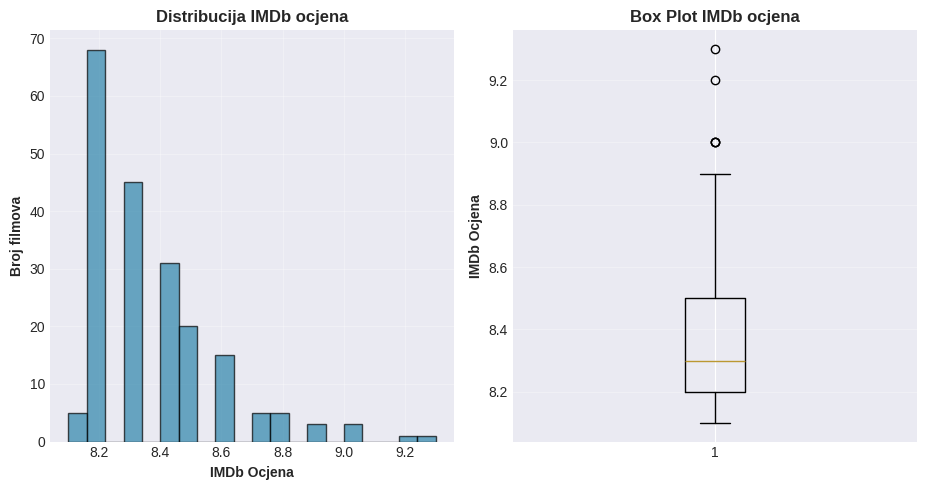

In [ ]:
plt.figure(figsize=(14, 5))

# Histogram
plt.subplot(1, 3, 1)
plt.hist(df_final['IMDB_Rating'].dropna(), bins=20,
         edgecolor='black', alpha=0.7, color='#2E86AB')
plt.xlabel('IMDb Ocjena', fontweight='bold')
plt.ylabel('Broj filmova', fontweight='bold')
plt.title('Distribucija IMDb ocjena', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)

#box plot
plt.subplot(1, 3, 2)
plt.boxplot(df_final['IMDB_Rating'].dropna(), vert=True)
plt.ylabel('IMDb Ocjena', fontweight='bold')
plt.title('Box Plot IMDb ocjena', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('01_rating_distribution.png', dpi=300, bbox_inches='tight')
plt.show()


Histogramom ocjena i pripadajućim box plot dijagramo možemo vidjeti da raspodjelu IMDb ocjena. Histogram nam pokazuje detaljan pregled koliko filmova ima koju ocjenu, dok box plot pokazuje najčečću, tipičnu ocjenu, raspon i odstupanja.

Prema histogramu najviše filmova ima ocjenu u rasponu od 8.1 do 8.4 te kako ocjena raste prema 9 broj filmova drastično se smanjuje, što govori da su visoke ocjene od 9.0 rijetke.

Prema box plotu medijan, srednja vrijednost jest 8.3, dok je većina ocjena filmova između 8.2 i 8.5. Također nekoliko filmova ima visoke ocjene od 9.0 do 9.3.

###Filmovi po žanrovima

S obzirom da smo vidjeli da su filmovi s visokim ocjenama rijetki zanimalo me koji su to onda filmovi s visokim ocjenama.

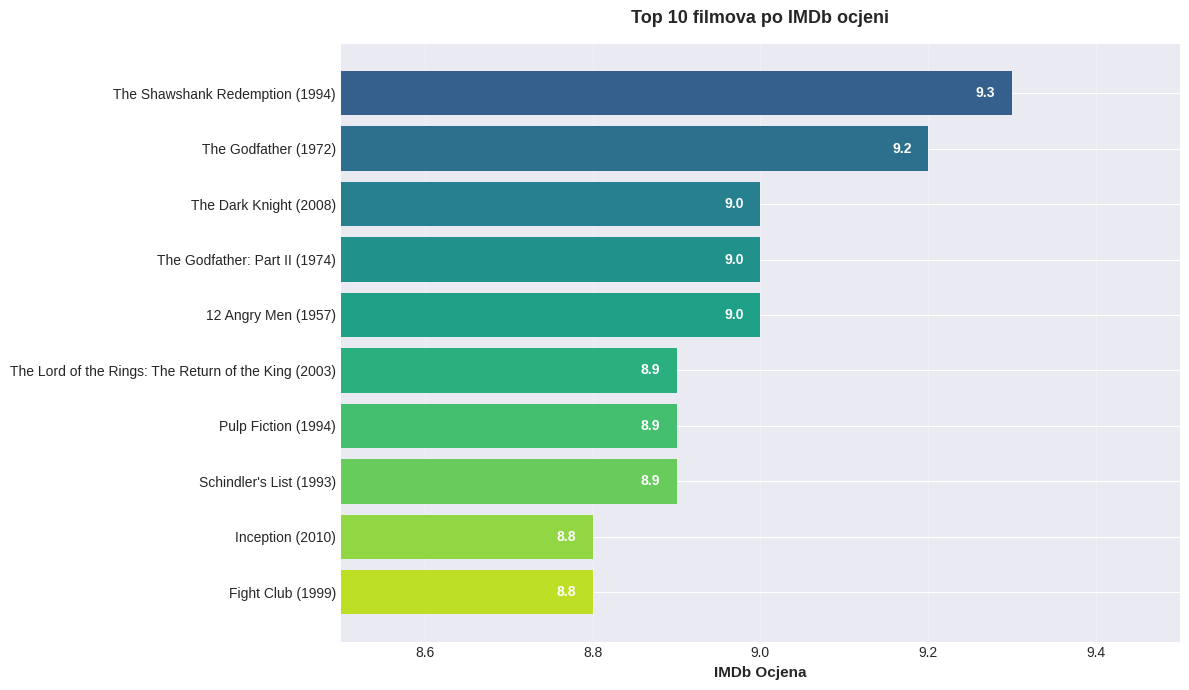

In [ ]:
top_10 = df_final.nlargest(10, 'IMDB_Rating')[
    ['Series_Title', 'IMDB_Rating', 'Released_Year', 'Director']
].reset_index(drop=True)

plt.figure(figsize=(12, 7))
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(top_10)))
bars = plt.barh(range(len(top_10)), top_10['IMDB_Rating'], color=colors)

# Postavi labele s naslovom i godinom
labels = [f"{row['Series_Title']} ({int(row['Released_Year'])})"
          for idx, row in top_10.iterrows()]
plt.yticks(range(len(top_10)), labels)

plt.xlabel('IMDb Ocjena', fontweight='bold', fontsize=11)
plt.title('Top 10 filmova po IMDb ocjeni', fontsize=13, fontweight='bold', pad=15)
plt.xlim(8.5, top_10['IMDB_Rating'].max() + 0.2)
plt.grid(True, alpha=0.3, axis='x')

# Dodaj vrijednosti na barove
for i, (idx, row) in enumerate(top_10.iterrows()):
    plt.text(row['IMDB_Rating'] - 0.02, i, f"{row['IMDB_Rating']:.1f}",
             va='center', ha='right', fontweight='bold',
             color='white', fontsize=10)

plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('02_top_10_movies.png', dpi=300, bbox_inches='tight')
plt.show()


Slika prikazuje dijagram deset najboljih filmova prema ocjenama, gdje možemo vidjeti sve prethodne iznimke te reći da je u skupu podatka najbolje ocijenjen film The Shawshank Redemption i 1994.

###Analiza trendova po godinama

Još sam u uvodu naglasila da želim prikazati i vidjeti kako je tekao razvoj filmske idustrije po godinama. Podatci će se grupirati po godinama te će se prikazati prosječna ocjena i broj filmova.

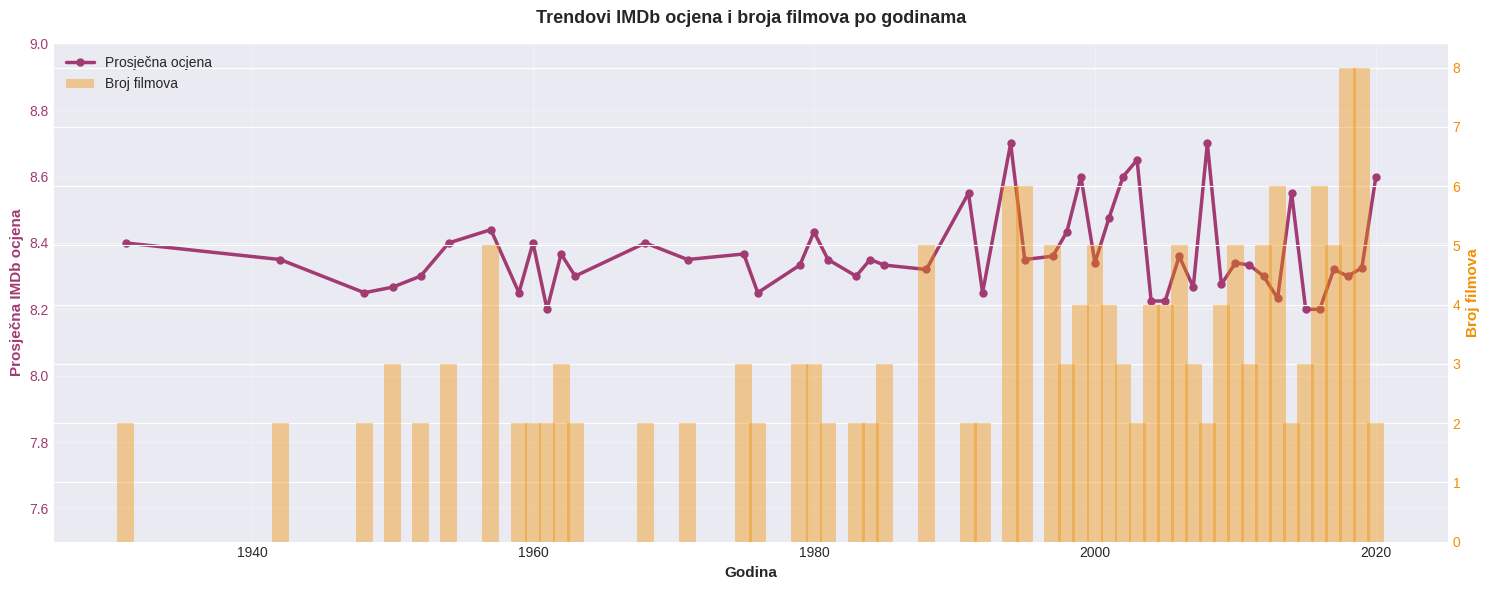

In [ ]:
# Grupiranje po godinama
yearly_stats = df_final.groupby('Released_Year').agg({
    'IMDB_Rating': 'mean',
    'Series_Title': 'count'
}).reset_index()
yearly_stats.columns = ['Year', 'Avg_Rating', 'Movie_Count']

# Filtriraj godine s najmanje 2 filma
yearly_stats = yearly_stats[yearly_stats['Movie_Count'] >= 2]

fig, ax1 = plt.subplots(figsize=(15, 6))

# Linija prosječne ocjene
color1 = '#A23B72'
ax1.set_xlabel('Godina', fontweight='bold', fontsize=11)
ax1.set_ylabel('Prosječna IMDb ocjena', color=color1, fontweight='bold', fontsize=11)
line = ax1.plot(yearly_stats['Year'], yearly_stats['Avg_Rating'],
                color=color1, linewidth=2.5, marker='o',
                markersize=5, label='Prosječna ocjena')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.grid(True, alpha=0.3)
ax1.set_ylim(7.5, 9.0)

# Stupci broja filmova
ax2 = ax1.twinx()
color2 = '#F18F01'
ax2.set_ylabel('Broj filmova', color=color2, fontweight='bold', fontsize=11)
bars = ax2.bar(yearly_stats['Year'], yearly_stats['Movie_Count'],
               alpha=0.4, color=color2, width=1.2, label='Broj filmova')
ax2.tick_params(axis='y', labelcolor=color2)

plt.title('Trendovi IMDb ocjena i broja filmova po godinama',
          fontsize=13, fontweight='bold', pad=15)

# Dodaj legendu
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)

fig.tight_layout()
plt.savefig('03_yearly_trends.png', dpi=300, bbox_inches='tight')
plt.show()

Graf odlično i jasno vizualizira razvoj filmske industrije po godinama koje se nalaze u skupu. Uz sami broj filmova kroz godinu prikazuje se i prosječna ocjena filmova u tom razdoblju.

Može se zaključiti da se filmska industrija počela snažno razvijati od početka 21. stoljeća jer vidimo znatni rast u broj proizvedenih filmova.

Prosječna ocjena ima zanimljiv linijski graf i prikazuje razne oscilacije. Značajnim razvojem filmova i ona više oscilira te cećimo je takva da je veća kada u toj godini ima manje filmova, nego u onoj godini kada ima manje filmova. Iz toga se može zaključiti da je publici jako bitna i kvaliteta filmova, a ne samo broj filmova reproduciranih u toj godini.

###Analiza žanrova

Filmovi mogu biti raznih žanrova te za dublju analizu potrebno je prikazati koji su bili popularni, koje žanrove publika najbolje ocjenjuje i koji žanr smatraju da je najpopularniji.

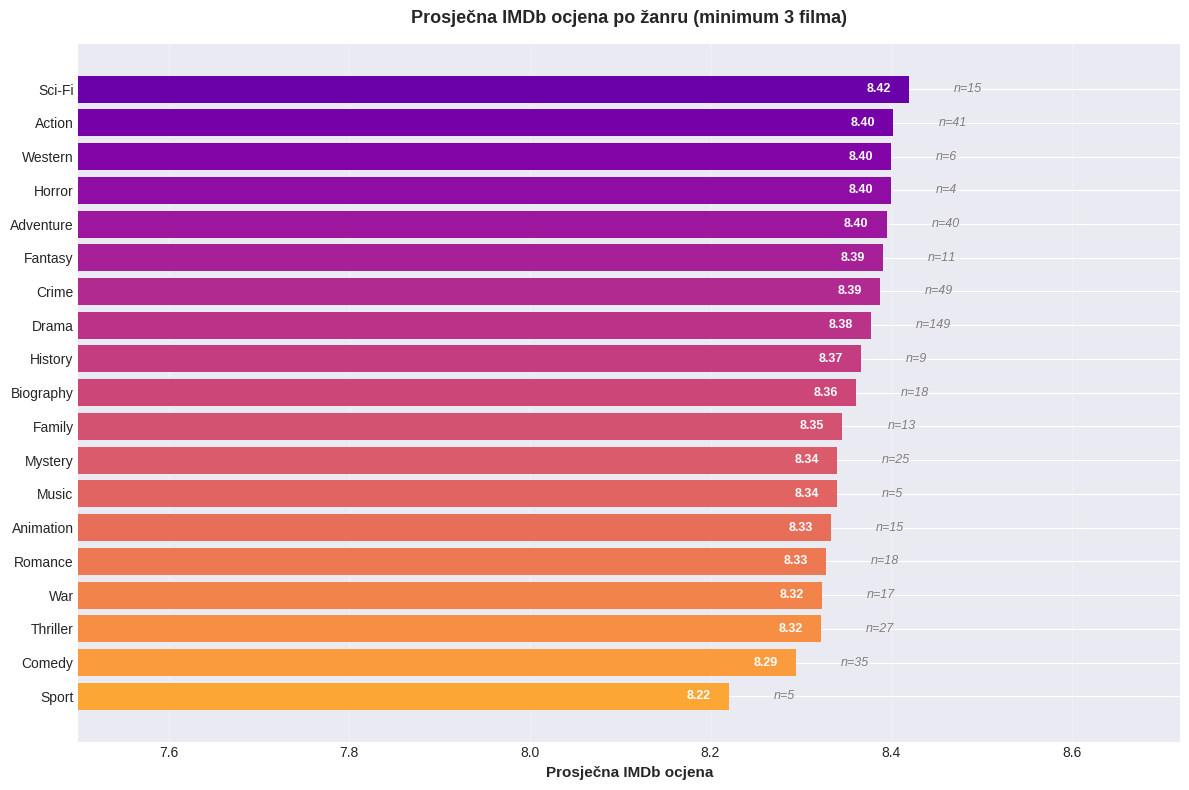

In [ ]:
# Ekstrahiraj sve žanrove
all_genres = []
for genres in df_final['Genre_List'].dropna():
    if isinstance(genres, list):
        all_genres.extend([g.strip() for g in genres])

genre_counts = Counter(all_genres)

# Analiza po žanru
genre_ratings = []
for genre in genre_counts.keys():
    genre_movies = df_final[df_final['Genre_List'].apply(
        lambda x: isinstance(x, list) and genre in x
    )]

    if len(genre_movies) >= 3:  # Minimum 3 filma
        genre_ratings.append({
            'Genre': genre,
            'Avg_Rating': genre_movies['IMDB_Rating'].mean(),
            'Count': len(genre_movies)
        })

genre_df = pd.DataFrame(genre_ratings).sort_values('Avg_Rating', ascending=False)

# Vizualizacija
plt.figure(figsize=(12, 8))
colors = plt.cm.plasma(np.linspace(0.2, 0.8, len(genre_df)))
bars = plt.barh(range(len(genre_df)), genre_df['Avg_Rating'], color=colors)
plt.yticks(range(len(genre_df)), genre_df['Genre'])
plt.xlabel('Prosječna IMDb ocjena', fontweight='bold', fontsize=11)
plt.title('Prosječna IMDb ocjena po žanru (minimum 3 filma)',
          fontsize=13, fontweight='bold', pad=15)
plt.xlim(7.5, genre_df['Avg_Rating'].max() + 0.3)
plt.grid(True, alpha=0.3, axis='x')

# Dodaj broj filmova
for i, (idx, row) in enumerate(genre_df.iterrows()):
    plt.text(row['Avg_Rating'] + 0.05, i,
             f"n={int(row['Count'])}",
             va='center', fontsize=9, style='italic', color='gray')
    plt.text(row['Avg_Rating'] - 0.02, i,
             f"{row['Avg_Rating']:.2f}",
             va='center', ha='right', fontweight='bold',
             color='white', fontsize=9)

plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('04_genre_analysis.png', dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
print(f"\nNajpopularniji žanr: {genre_df.iloc[0]['Genre']} "
      f"({genre_df.iloc[0]['Avg_Rating']:.2f})")


Najpopularniji žanr: Sci-Fi (8.42)


Prema ocjenama i publcic najpopularniji žanr jest znanstvena fantastika.
Drugo mjesto prema ocjenama dijele čak četiri žanra: Akcija, Kaubojci, Horor i Avanturistički. Deseto mjesto pripada sportu kao filmskom žanru.

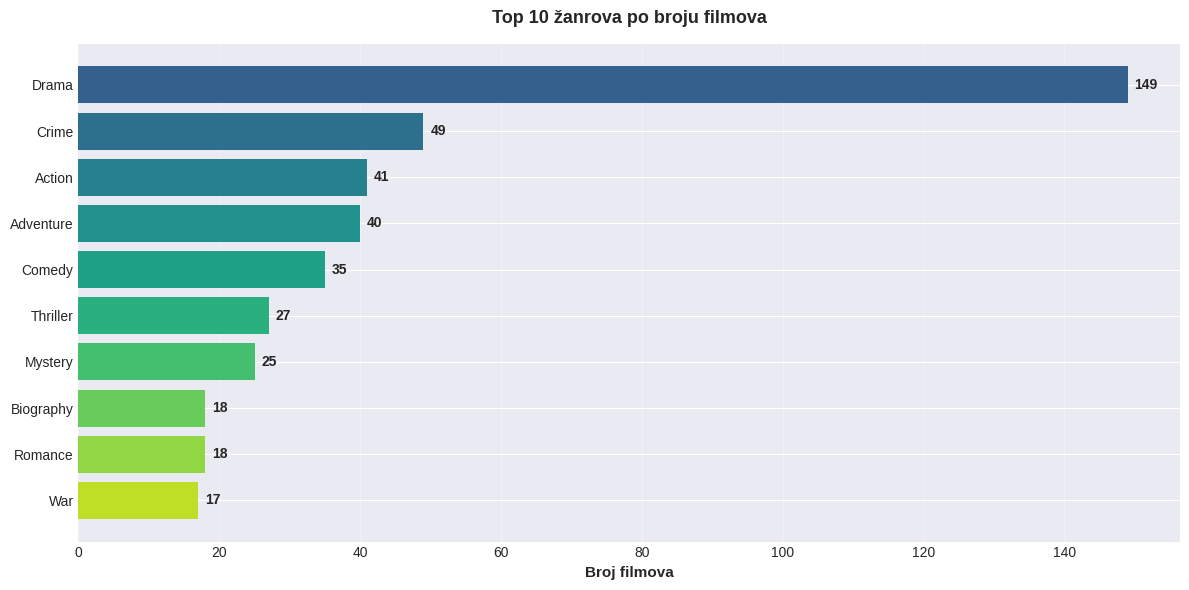

In [ ]:
#top 10 žanrova po broju filmova
top_genres = pd.DataFrame(genre_counts.most_common(10),
                          columns=['Genre', 'Count'])

plt.figure(figsize=(12, 6))
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(top_genres)))
bars = plt.barh(range(len(top_genres)), top_genres['Count'], color=colors)
plt.yticks(range(len(top_genres)), top_genres['Genre'])
plt.xlabel('Broj filmova', fontweight='bold', fontsize=11)
plt.title('Top 10 žanrova po broju filmova',
          fontsize=13, fontweight='bold', pad=15)
plt.grid(True, alpha=0.3, axis='x')

# Dodaj vrijednosti
for i, (idx, row) in enumerate(top_genres.iterrows()):
    plt.text(row['Count'] + 1, i, str(int(row['Count'])),
             va='center', fontweight='bold', fontsize=10)

plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('05_top_genres.png', dpi=300, bbox_inches='tight')
plt.show()


Analizom žanrova prema broju filmova, možemo zaključiti da je tu najpopularnija drama kojoj pripada čak 149 od 202 filma u bazi.

###Box office i ocjene

Kod analize filmske industrije bitno je prikazati i povezanost zarade s ocjenjivanjem.

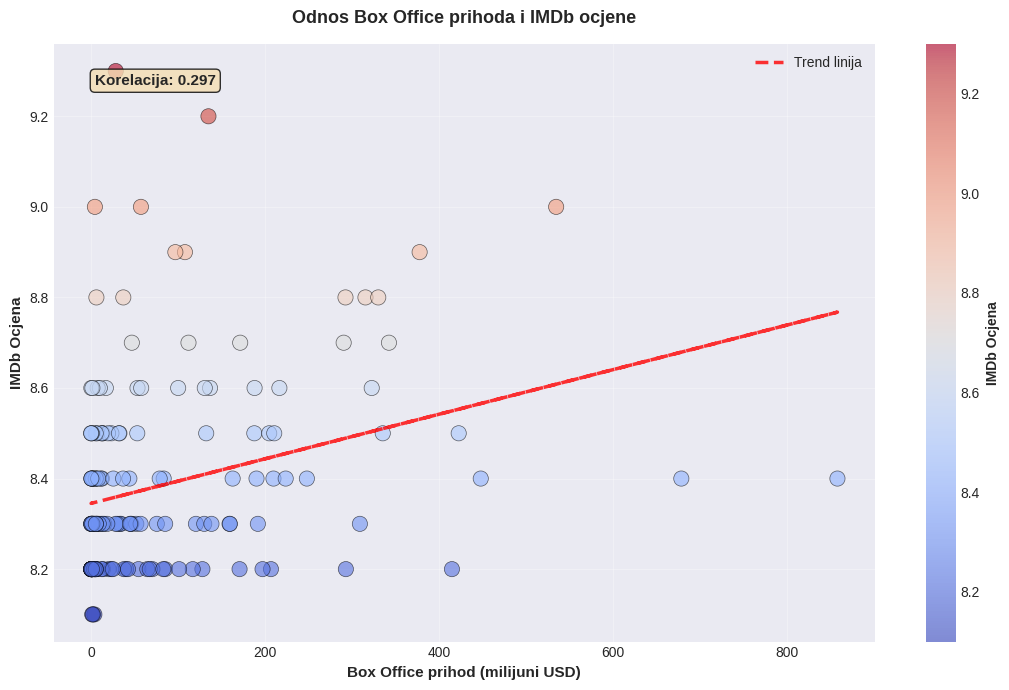

In [ ]:
df_box = df_final[df_final['BoxOffice_USD'].notna()].copy()

if len(df_box) >= 10:
    plt.figure(figsize=(11, 7))

    scatter = plt.scatter(
        df_box['BoxOffice_USD'] / 1e6,  # Milijuni
        df_box['IMDB_Rating'],
        alpha=0.6,
        s=120,
        c=df_box['IMDB_Rating'],
        cmap='coolwarm',
        edgecolors='black',
        linewidth=0.5
    )

    plt.xlabel('Box Office prihod (milijuni USD)', fontweight='bold', fontsize=11)
    plt.ylabel('IMDb Ocjena', fontweight='bold', fontsize=11)
    plt.title('Odnos Box Office prihoda i IMDb ocjene',
              fontsize=13, fontweight='bold', pad=15)

    cbar = plt.colorbar(scatter)
    cbar.set_label('IMDb Ocjena', fontweight='bold')
    plt.grid(True, alpha=0.3)

    # Trend linija
    z = np.polyfit(df_box['BoxOffice_USD'], df_box['IMDB_Rating'], 1)
    p = np.poly1d(z)
    plt.plot(df_box['BoxOffice_USD']/1e6,
             p(df_box['BoxOffice_USD']),
             "r--", alpha=0.8, linewidth=2.5, label='Trend linija')

    # Korelacija
    correlation = df_box['BoxOffice_USD'].corr(df_box['IMDB_Rating'])
    plt.text(0.05, 0.95, f'Korelacija: {correlation:.3f}',
             transform=plt.gca().transAxes,
             fontsize=11, fontweight='bold',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
             verticalalignment='top')

    plt.legend(fontsize=10)
    plt.tight_layout()
    plt.savefig('06_boxoffice_rating.png', dpi=300, bbox_inches='tight')
    plt.show()


Ovaj raspršeni dijagram prikazuje odnos između BOx Office prihoda i IMDb ocjene filma, tako da svaka točka predstavlja jedan film.

Boja točke ovisi o IMDb ocjeni te možemo vidjeti da je većina filmova ispod 200 milijuna dolara s ocjenama od 8.2 do 8.5 čime se može zaključiti da visoka zarada nije mužno povezana s iznimno visokom ocjenom.

Crvena isprekidana linija predstavlja linearni trend, koji je lagano rastući pa s većim prihodima, ocjena u nekakavom prosjeku blago raste. Veza nije jaka jer je taj nagib mali.

Na grafu još možemo vidjeti i korelaciju od 0.297 koja označava slabu do umjerenu pozitivnu korelaciju između prihoda i ocjena. Odnosno, veći Box Office prihodi blago su povezani s višim IMDB ocjenama što znači da velika zarada ne znači automatski da će film imati visoku ocjenu. Komercijalni uspejh filma nije snažan pokazatelj njegove kvalitete prema IMDb ocjenama.

###Metascore i IMDB ocjene

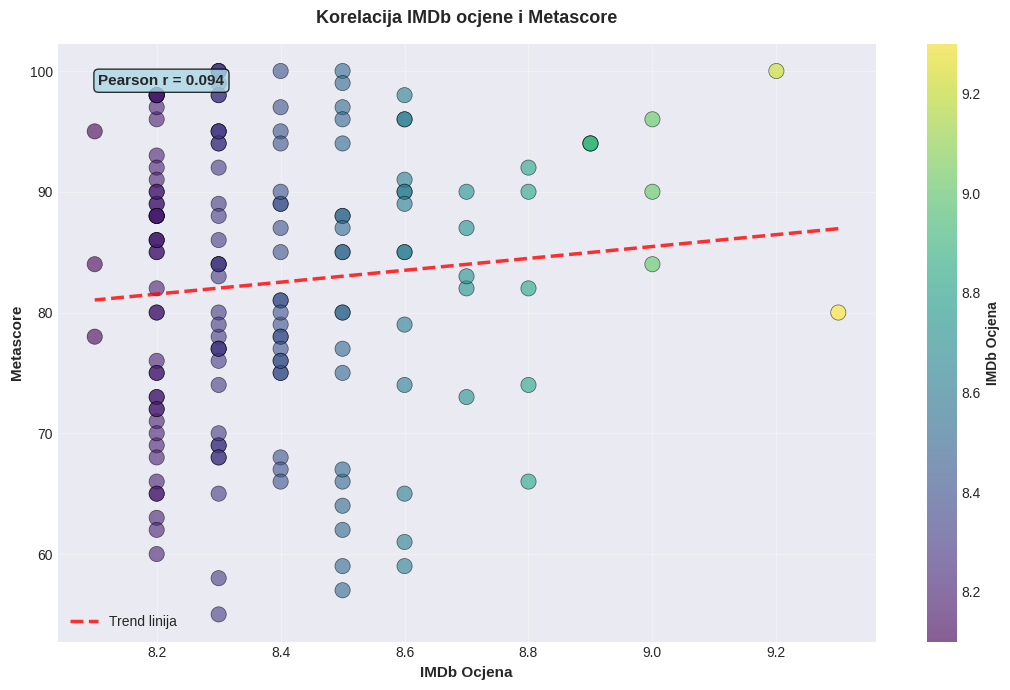

In [ ]:
# usporedba Metaascore s ocjenama
df_meta = df_final[df_final['Meta_score'].notna()].copy()

if len(df_meta) >= 10:
    plt.figure(figsize=(11, 7))

    scatter = plt.scatter(
        df_meta['IMDB_Rating'],
        df_meta['Meta_score'],
        alpha=0.6,
        s=120,
        c=df_meta['IMDB_Rating'],
        cmap='viridis',
        edgecolors='black',
        linewidth=0.5
    )

    plt.xlabel('IMDb Ocjena', fontweight='bold', fontsize=11)
    plt.ylabel('Metascore', fontweight='bold', fontsize=11)
    plt.title('Korelacija IMDb ocjene i Metascore',
              fontsize=13, fontweight='bold', pad=15)

    cbar = plt.colorbar(scatter)
    cbar.set_label('IMDb Ocjena', fontweight='bold')
    plt.grid(True, alpha=0.3)

    # Trend linija
    z = np.polyfit(df_meta['IMDB_Rating'], df_meta['Meta_score'], 1)
    p = np.poly1d(z)
    plt.plot(df_meta['IMDB_Rating'],
             p(df_meta['IMDB_Rating']),
             "r--", alpha=0.8, linewidth=2.5, label='Trend linija')

    # Korelacija
    correlation = df_meta['IMDB_Rating'].corr(df_meta['Meta_score'])
    plt.text(0.05, 0.95, f'Pearson r = {correlation:.3f}',
             transform=plt.gca().transAxes,
             fontsize=11, fontweight='bold',
             bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8),
             verticalalignment='top')

    plt.legend(fontsize=10)
    plt.tight_layout()
    plt.savefig('07_metascore_imdb.png', dpi=300, bbox_inches='tight')
    plt.show()


Raspršeni dijagram uspoređuje ocjene publike s ocjenama profesionalnih kritičara filmova.

Svaka točka predstavlja jedan film a njena boja IMDb ocjenu te je odmah vidjljivo da za istu ocjenu Metascore može biti vrlo različit, odnosno u velikom rasponu od 60 do 90, što govori da se publika i kritičari često ne slažu oko kvalitete filma.

Također kao i u prethodnom slučaju linija trenda ima blagi uzlazni trend, no veza je slaba, pa se može reći da kako IMDb ocjena raste, Metascore u prosjeku malo raste.

Pearsonova korellacija iznosi 0.094. štpo sugerira gotovo nikakvu lineranu povezanost, odnosno ona je vrlo slaba pozitivna korelacija. U praksi to označava da ocjena publike gotovo nikad ne predviđa Metascore kritičara.

Zaključno, vidljivo je da filmovi s istom IMDb ocjenom mogu imati znatno različite Metascore vrijednosti, što sugerira da se percepcija kvalitete filma kod publike i profesionalnih kritičara često razlikuje.

###Heatmap korelacija

S obzirom da sam u prosla dva primjera uvidjela da nema velike povezanosti između raznih čimbenika, odlučila sam napraviti toplinsku kartu svih numeričkih vrijednosti kako bi vidjela postoji li jača korelacija između nekih numeričkih vrijednosti.

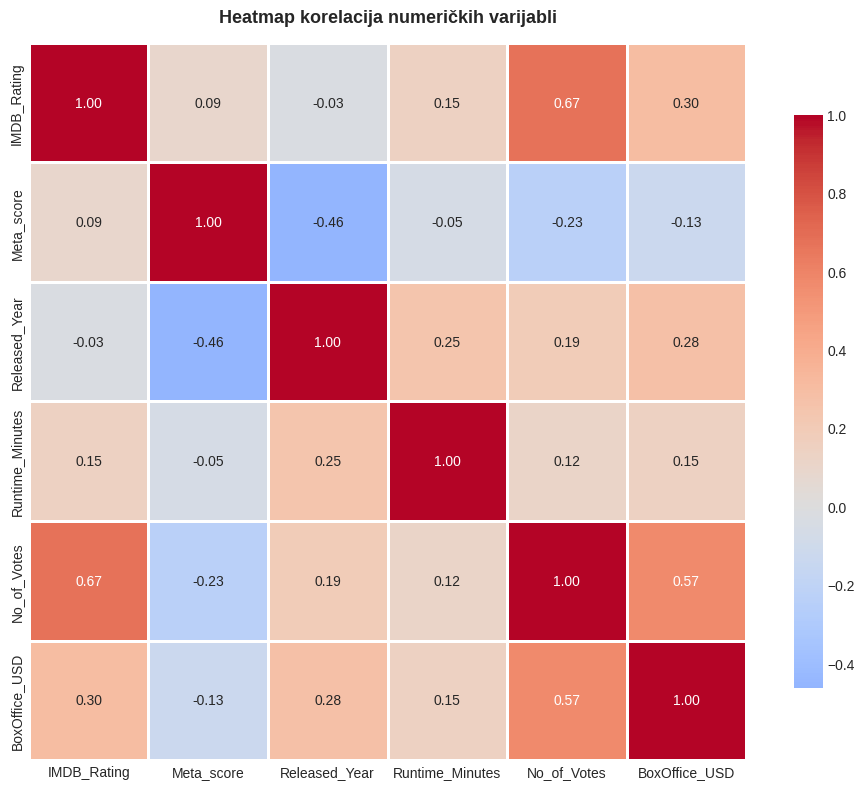

In [ ]:
# Odaberi numeričke stupce
numeric_cols = ['IMDB_Rating', 'Meta_score', 'Released_Year',
                'Runtime_Minutes', 'No_of_Votes', 'BoxOffice_USD']

# Filtriraj stupce koji postoje
available_cols = [col for col in numeric_cols if col in df_final.columns]
corr_data = df_final[available_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_data, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=1,
            cbar_kws={"shrink": 0.8})
plt.title('Heatmap korelacija numeričkih varijabli',
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('08_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()


Ova toplinska mapa ukazuje da ovaj mali broj numeričkih vrijednosti i podataka ima jako slabu međusobnu korelaciju.

Najveću poveznast od svega 0.67 imaju broj glasova i IMDB ocjene, što i ima smisla.

##Kritički osvrt

###Kritički osvrt na projekt

Napravljeni projekt odlično objedinjuje do sada sve predstavljeno i naučeno na kolegiju Programiranje za anlizu podataka, što ga čini odličnim za provjeru i unaprijeđenje stečenih znanja.

Naglasila bih kako sam uživala u cijelom procesu izrade, a posebno u izradi baze podataka i pripadajućih REST API servisa. Iako bi sada možda da ponovo radim projekt odabrala neki način pristupa podacima koji je više korsinički orijentiran i reprezentativan.

Integracija heterogenih izvora je moguća i izvediva, no u ovom slučaju je malo ograničeno jer OMDb API ima na besplatnoj verziji ograničen broj poziva te oslanjanje na sami naziv filma i godinu može potencijalno uzrokova neprecizna podudaranja. Zbog toga sam morala ograničiti broj zahtjeva koje salje prema API-ju kao i njihovo vrijeme slanja.

Smatram da je sustav stabilan i skalabilan do određene mjere, no korištene tehnologije kao što su SQLite baza i lokalna implementacija FastAPI serivisa nisu najoptimalnija rješenja za obradu velikih količina podataka ili visoku razinu paralelnih zahtjeva. Unatoč tim ograničenjima, projekt uspješno demonstrira ključne koncepte obrade, čišćenja, integracije i analize podataka te može poslužiti kao temelj za daljnu nadogradnju tipa strojno učenje kao naprednija analiza.


Kako radimo s javno dostupnim podacima bitno je naglasiti i etički aspekt. Podaci koje koristim su isključivo javno dostupni te anomizirani, čime se ne narušava privatnost korisnika, a analiza rezultata ne dovodi do individualne identifikacije niti diskriminacije korisnika ili sadržaja.

### Kritički osvrt na upotrebu AI tehnologija

U radu sam koristila AI tehnologije i to Claude i ChatGPT. Oba alata sma koristila radi debugiranja. Prilikom kreiranja baze imala sam problema pa sam zamolila Claude kao alat da mi pomogne i odlično je napravio posao bez dodatnih promptova. Dok sam ChatGPT koristila kod REST API jer sam imala problema sa portom na kojem nisam mogla prekinuti izvođenje programa. Chat mi je na kraju pomogao, no trebalo je nekoliko promtova da shvati koji je problem i kako ga riješiti.
Linkovi na razgovore bit će dostupni u literaturi.

##Zaključak

U projektu provedena je analiza popularnosti filmova integracijom korisničkh podataka iz heterogenih izvora, Movie Dataseta preuzetoga sa Kaggle sustava te obuhvaćanje dodatnih informacija putem OMDb API-ja. Projekt je obuhvatio cjelokupan proces rada sa samim podacima, od samog pronalaska podataka i prikupljanja, zatim predprocesiranja i integracije do pohrane u bazu podataka, izrade REST API sučelja te sustavne analize i vizualizacije integriranih podataka.

Dobiveni rezultati omogućili su usporedbu IMDb ocjena i ocjena profesionalnih kritičara, analizu trendova kroz godine u filmskoj industriji te identifikaciju najpopularnijih filmova i žanrova. Time se ostvaruje glavni cilj projekta, a implementirano rješenje potvrđuje da se heterogreni izvori podataka mogu učinkovito integrirati i analizirati korištenjem čak i jednostavnijih tehnologija.

Upotreba AI tehnologija može olakšati izradu projekta i lakše uklanjanje pogrešaka, ako se zna odabrati alat koji neće dodatno zakomplicirati stvari.

Smatram da je projekt uspješno ispunio sve tehničke i analitičke zahtjeve u okviru kolegija. Projekt kao takav predstavlja dobru osonu za daljnji razvoj, primjerice uvođenjem naprednijih analitičkih metoda, većih skupova podataka ili boljim tehnologijama pohrane podataka.

##Literatura

[1] H. Shankhdhar, "IMDB Dataset of Top 1000 Movies and TV Shows,"
    Kaggle, 2023. [Online]. Available:
    https://www.kaggle.com/datasets/harshitshankhdhar/imdb-dataset-of-top-1000-movies-and-tv-shows

[2] "The Open Movie Database," OMDb API. [Online]. Available:
    http://www.omdbapi.com/

[3] W. McKinney, *Python Basics*, wesmckinney.com. [Online]. Available: https://wesmckinney.com/book/python-basics. [Accessed: Jan. 2026].

[4] Fakultet informatike i digitalnih tehnologija, “[Pzap]_Applied_(Engineering)_Concepts_in_Data_Analytics_shared (2)”, Moodle sustav kolegija Programiranje za analizu i obradu podataka, interne nastavne bilješke, 2025.


[5] Claude -  Baza podataka https://claude.ai/share/0b356c47-97a1-4ae3-865d-83ab269486c7

[6] ChatGPT - Pogreška kod servera https://chatgpt.com/share/69716228-fc04-800e-95d5-9497917ca3e5

